In [2]:
!pip install seaborn

zsh:1: /Users/erroldmello/Documents/college/pawlensai/roboflowvenv/bin/pip: bad interpreter: /Users/erroldmello/Downloads/pawlensai/roboflowvenv/bin/python3.12: no such file or directory


/Users/erroldmello/Documents/college/pawlensai/roboflowvenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


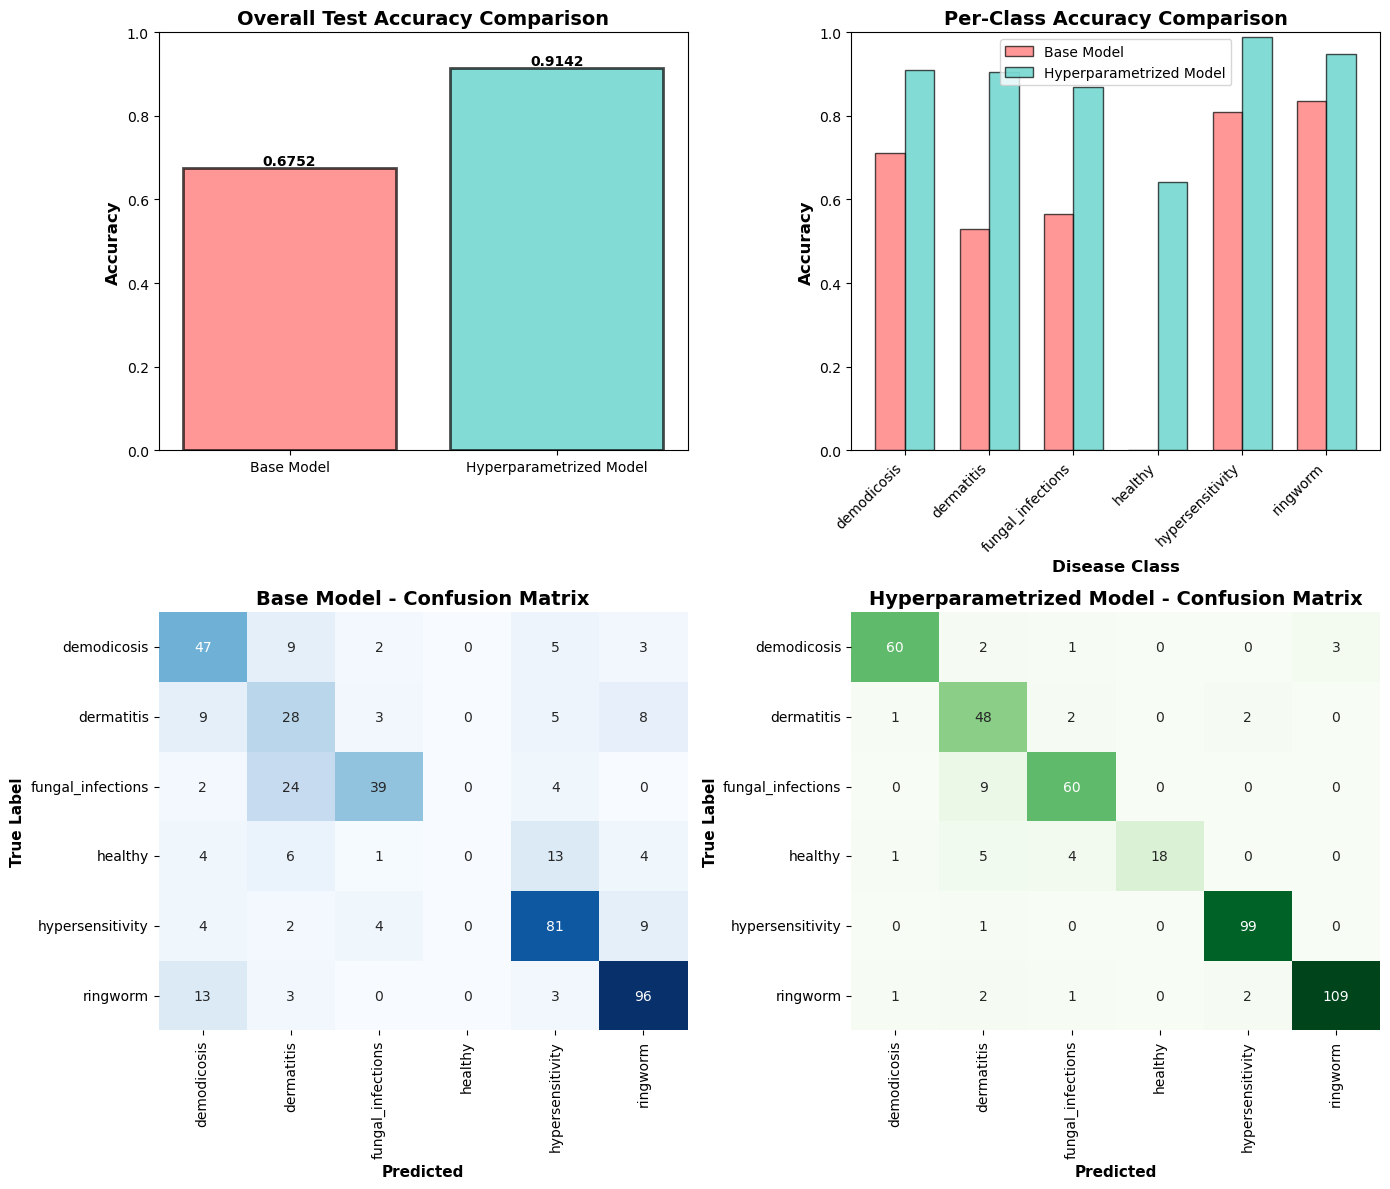

MODEL COMPARISON SUMMARY

Base Model Test Accuracy:              0.6752
Hyperparametrized Model Test Accuracy: 0.9142
Improvement:                           0.2390 (23.90%)

Per-Class Accuracy:
Class                Base         Hyperopt     Difference  
--------------------------------------------------------
demodicosis          0.7121       0.9091       +0.1970
dermatitis           0.5283       0.9057       +0.3774
fungal_infections    0.5652       0.8696       +0.3043
healthy              0.0000       0.6429       +0.6429
hypersensitivity     0.8100       0.9900       +0.1800
ringworm             0.8348       0.9478       +0.1130


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ============= CONFIG =============
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_DIR = "dataset"
BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_CLASSES = 6

CLASS_NAMES = [
    "demodicosis",
    "dermatitis",
    "fungal_infections",
    "healthy",
    "hypersensitivity",
    "ringworm"
]

# ============= DATA =============
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

test_ds = datasets.ImageFolder(
    f"{DATA_DIR}/test",
    transform=val_transform
)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ============= LOAD MODELS =============
model_base = timm.create_model(
    "vit_base_patch16_224",
    pretrained=False,
    num_classes=NUM_CLASSES
).to(DEVICE)

model_hyperopt = timm.create_model(
    "vit_base_patch16_224",
    pretrained=False,
    num_classes=NUM_CLASSES
).to(DEVICE)

# Load weights
base_weights = torch.load("vit_skin_disease.pth", map_location=DEVICE)
hyperopt_weights = torch.load("best_vit_model.pth", map_location=DEVICE)

model_base.load_state_dict(base_weights)
model_hyperopt.load_state_dict(hyperopt_weights)

model_base.eval()
model_hyperopt.eval()

# ============= EVALUATE BOTH MODELS =============
def evaluate_model(model, test_loader, model_name):
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu()
            
            all_preds.append(preds.numpy())
            all_labels.append(labels.numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    
    accuracy = np.mean(all_preds == all_labels)
    cm = confusion_matrix(all_labels, all_preds)
    
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    
    return {
        'name': model_name,
        'accuracy': accuracy,
        'preds': all_preds,
        'labels': all_labels,
        'cm': cm,
        'per_class_acc': per_class_acc
    }

results_base = evaluate_model(model_base, test_loader, "Base Model")
results_hyperopt = evaluate_model(model_hyperopt, test_loader, "Hyperparametrized Model")

# ============= VISUALIZATION =============
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Accuracy Comparison
ax = axes[0, 0]
models = [results_base['name'], results_hyperopt['name']]
accuracies = [results_base['accuracy'], results_hyperopt['accuracy']]
colors = ['#FF6B6B', '#4ECDC4']
bars = ax.bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Overall Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. Per-Class Accuracy Comparison
ax = axes[0, 1]
x = np.arange(len(CLASS_NAMES))
width = 0.35
ax.bar(x - width/2, results_base['per_class_acc'], width, label=results_base['name'], 
       color=colors[0], alpha=0.7, edgecolor='black')
ax.bar(x + width/2, results_hyperopt['per_class_acc'], width, label=results_hyperopt['name'], 
       color=colors[1], alpha=0.7, edgecolor='black')
ax.set_xlabel('Disease Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1])

# 3. Confusion Matrix - Base Model
ax = axes[1, 0]
sns.heatmap(results_base['cm'], annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, cbar=False)
ax.set_title(f"{results_base['name']} - Confusion Matrix", fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax.set_ylabel('True Label', fontsize=11, fontweight='bold')

# 4. Confusion Matrix - Hyperparametrized Model
ax = axes[1, 1]
sns.heatmap(results_hyperopt['cm'], annot=True, fmt='d', cmap='Greens', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, cbar=False)
ax.set_title(f"{results_hyperopt['name']} - Confusion Matrix", fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax.set_ylabel('True Label', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ============= SUMMARY STATS =============
print("="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(f"\nBase Model Test Accuracy:              {results_base['accuracy']:.4f}")
print(f"Hyperparametrized Model Test Accuracy: {results_hyperopt['accuracy']:.4f}")
print(f"Improvement:                           {(results_hyperopt['accuracy'] - results_base['accuracy']):.4f} "
      f"({100*(results_hyperopt['accuracy'] - results_base['accuracy']):.2f}%)")
print("\nPer-Class Accuracy:")
print(f"{'Class':<20} {'Base':<12} {'Hyperopt':<12} {'Difference':<12}")
print("-"*56)
for i, class_name in enumerate(CLASS_NAMES):
    base_acc = results_base['per_class_acc'][i]
    hyp_acc = results_hyperopt['per_class_acc'][i]
    diff = hyp_acc - base_acc
    print(f"{class_name:<20} {base_acc:.4f}       {hyp_acc:.4f}       {diff:+.4f}")